In [1]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv('hand_data.csv')

# 2. Check if data is balanced
print("Frames recorded per gesture:")
print(df['label'].value_counts())

# 3. Define Features (X) and Target (y)
X = df.drop('label', axis=1)
y = df['label']

Frames recorded per gesture:
label
Neutral    1207
Left       1181
Down       1113
Right      1074
Up         1071
Name: count, dtype: int64


In [2]:
# Split data: 80% for training, 20% for testing the AI
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the Random Forest (a powerful AI model for gesture recognition)
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the "Brain"
model.fit(X_train, y_train)

# Check how smart it is
y_pred = model.predict(X_test)
print(f"AI Training Complete! Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

AI Training Complete! Accuracy: 99.73%


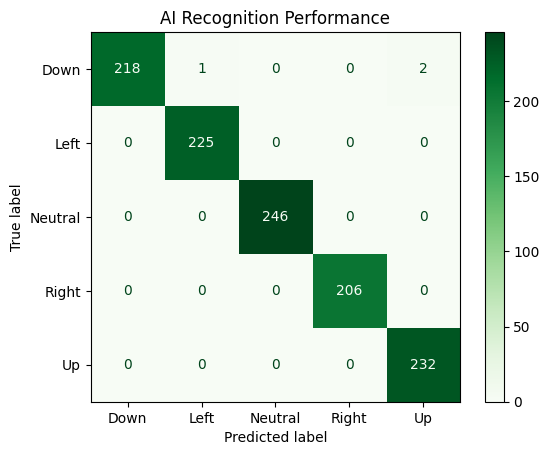

File 'gesture_rf_model.pkl' created! Your AI is ready to play the game.


In [3]:
# Create a visual report (Confusion Matrix)
# This shows exactly which gestures the AI might be confusing
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap='Greens')
plt.title("AI Recognition Performance")
plt.show()

# SAVE THE MODEL FILE
joblib.dump(model, 'gesture_rf_model.pkl')
print("File 'gesture_rf_model.pkl' created! Your AI is ready to play the game.")
